
# Random Forest Volatility Forecasting Notebook

This notebook mirrors the current setup from your LSTM notebook, but swaps in a **RandomForestRegressor**.

What it does:
- loads the same stock and cluster data
- uses the same engineered features
- keeps the same **train / validation / unseen** time split logic
- predicts **future 21-day volatility**
- compares Random Forest against the simple baseline: **`ret_std_21`**

Important modeling choice here:
- the LSTM notebook used **21-day sequences**
- this Random Forest notebook uses the **endpoint row at time t** as a tabular sample
- that is usually the cleaner choice for tree models with already-engineered rolling features


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:

# =========================
# File paths - update if needed
# =========================

csv_path = "data/sp500_5yr_with_sectors_weights.csv"
cluster_map_path = "data/sp500_stock_cluster_map.csv"

# =========================
# Time split boundaries
# =========================

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

# Forecast setup
HORIZON = 21
RANDOM_STATE = 42


In [3]:

# Load main panel

df = pd.read_csv(csv_path)
if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Load cluster map and merge
cluster_map = pd.read_csv(cluster_map_path)
df = df.merge(
    cluster_map[["Symbol", "cluster", "Cluster_name"]],
    on="Symbol",
    how="left"
)

df["is_high_risk_cluster"] = (df["cluster"] == 1).astype(int)

print(df.shape)
print(df[["Date", "Symbol", "Close"]].head())
print("Missing cluster labels:", df["cluster"].isna().sum())


(626169, 12)
        Date Symbol       Close
0 2021-03-22      A  119.463020
1 2021-03-23      A  117.887703
2 2021-03-24      A  116.785934
3 2021-03-25      A  117.810394
4 2021-03-26      A  121.424896
Missing cluster labels: 1371


In [4]:

# Keep only stocks that appear in all 3 periods

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)
df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())
print(df.shape)


Common stocks: 499
(624798, 12)


In [5]:

# Feature engineering

def engineer_features(panel_df):
    panel_df = panel_df.copy()
    panel_df = panel_df.sort_values(["Symbol", "Date"])

    g = panel_df.groupby("Symbol")

    # simple 1 day return
    panel_df["ret_1"] = g["Close"].pct_change()

    # target: std of stock's daily returns from t+1 to t+21
    panel_df["target_vol_21d"] = (
        g["ret_1"].transform(lambda s: s.shift(-1).rolling(21).std().shift(-20))
    )

    # today's absolute return
    panel_df["ret_abs_1"] = panel_df["ret_1"].abs()

    # std of returns over past 5, 10, 21 days
    for w in [5, 10, 21]:
        panel_df[f"ret_std_{w}"] = g["ret_1"].transform(lambda s: s.rolling(w).std())

    # daily intraday range
    panel_df["hl_range"] = (panel_df["High"] - panel_df["Low"]) / panel_df["Close"]

    for w in [5, 21]:
        panel_df[f"hl_range_mean_{w}"] = g["hl_range"].transform(lambda s: s.rolling(w).mean())

    # relative volume
    for w in [5, 21]:
        panel_df[f"vol_mean_{w}"] = g["Volume"].transform(lambda s: s.rolling(w).mean())
        panel_df[f"vol_rel_{w}"] = panel_df["Volume"] / panel_df[f"vol_mean_{w}"]

    return panel_df


In [6]:

# Split raw data first, same as current notebook

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

# Save unseen holdout raw data so we can re-engineer it later with trailing dev context
unseen_df.to_csv("data/unseen_holdout_raw.csv", index=False)

# Development panel = train + val only
# Keep raw copy because we need trailing context later for unseen

df_dev_raw = (
    pd.concat([train_df, val_df], axis=0)
    .sort_values(["Symbol", "Date"])
    .reset_index(drop=True)
    .copy()
)

print("Dev raw shape:", df_dev_raw.shape)


Train shape: (374800, 12)
Val shape: (124750, 12)
Unseen shape: (125248, 12)
Dev raw shape: (499550, 12)


In [7]:

# Apply feature engineering to development data

df_dev = engineer_features(df_dev_raw)

feature_cols = [
    "ret_abs_1",
    "ret_std_5",
    "ret_std_10",
    "ret_std_21",
    "hl_range_mean_5",
    "hl_range_mean_21",
    "vol_rel_5",
    "vol_rel_21",
    "is_high_risk_cluster",
]

target_col = "target_vol_21d"

print(df_dev.columns.tolist())


['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'Security', 'Sector', 'cluster', 'Cluster_name', 'is_high_risk_cluster', 'ret_1', 'target_vol_21d', 'ret_abs_1', 'ret_std_5', 'ret_std_10', 'ret_std_21', 'hl_range', 'hl_range_mean_5', 'hl_range_mean_21', 'vol_mean_5', 'vol_rel_5', 'vol_mean_21', 'vol_rel_21']


In [8]:

# Build valid tabular modeling rows
# Each row represents endpoint date t.
# The target window (t+1 ... t+21) must stay inside the same split.

def build_tabular_rows(panel_df, feature_cols, target_col, split_start, split_end, horizon=21):
    out = panel_df.copy()
    out = out.sort_values(["Symbol", "Date"]).copy()

    # drop rows with missing / non-finite features or target
    out = out.dropna(subset=feature_cols + [target_col]).copy()
    finite_mask = np.isfinite(out[feature_cols + [target_col]]).all(axis=1)
    out = out.loc[finite_mask].copy()

    g = out.groupby("Symbol")
    out["date_plus_horizon"] = g["Date"].shift(-horizon)

    out = out[
        (out["Date"] >= split_start)
        & (out["Date"] <= split_end)
        & (out["date_plus_horizon"].notna())
        & (out["date_plus_horizon"] <= split_end)
    ].copy()

    return out

train_feat = build_tabular_rows(df_dev, feature_cols, target_col, TRAIN_START, TRAIN_END, HORIZON)
val_feat   = build_tabular_rows(df_dev, feature_cols, target_col, VAL_START, VAL_END, HORIZON)

print("train_feat:", train_feat.shape)
print("val_feat:", val_feat.shape)


train_feat: (353821, 26)
val_feat: (103781, 26)


In [9]:

# Training and validation matrices

X_train = train_feat[feature_cols].copy()
y_train = train_feat[target_col].copy()

X_val = val_feat[feature_cols].copy()
y_val = val_feat[target_col].copy()

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(353821, 9) (353821,)
(103781, 9) (103781,)


In [10]:

# Random Forest model

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [11]:

# Validation predictions

val_results = val_feat[["Symbol", "Date", "Sector", "cluster", "Cluster_name", "ret_std_21"]].copy()
val_results["y_true"] = y_val.values
val_results["y_pred"] = rf.predict(X_val)
val_results["baseline_pred"] = val_results["ret_std_21"]

val_results.head()


,Symbol,Date,Sector,cluster,Cluster_name,ret_std_21,y_true,y_pred,baseline_pred
755,A,2024-03-21,Health Care,0.0,Lower-vol / steadier,0.014039,0.014448,0.015320,0.014039
756,A,2024-03-22,Health Care,0.0,Lower-vol / steadier,0.012771,0.017340,0.014526,0.012771
757,A,2024-03-25,Health Care,0.0,Lower-vol / steadier,0.013335,0.017325,0.016225,0.013335
758,A,2024-03-26,Health Care,0.0,Lower-vol / steadier,0.013486,0.017329,0.016279,0.013486
759,A,2024-03-27,Health Care,0.0,Lower-vol / steadier,0.013914,0.016776,0.016423,0.013914


In [12]:

# Validation metrics

def summarize_metrics(df_results, pred_col="y_pred"):
    return {
        "rmse": float(np.sqrt(mean_squared_error(df_results["y_true"], df_results[pred_col]))),
        "mae": float(mean_absolute_error(df_results["y_true"], df_results[pred_col])),
        "r2": float(r2_score(df_results["y_true"], df_results[pred_col])),
        "corr": float(df_results["y_true"].corr(df_results[pred_col])),
    }

rf_val_metrics = summarize_metrics(val_results, "y_pred")
base_val_metrics = summarize_metrics(val_results, "baseline_pred")

print("Validation Random Forest:", rf_val_metrics)
print("Validation Baseline:", base_val_metrics)


Validation Random Forest: {'rmse': 0.007261041788746323, 'mae': 0.00463525226985092, 'r2': 0.35633521657948863, 'corr': 0.5991162497145066}
Validation Baseline: {'rmse': 0.009551354546655235, 'mae': 0.006199224649093266, 'r2': -0.11376049323839577, 'corr': 0.43795026906633633}


In [13]:

# Validation by stock

rows = []
for symbol, g in val_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    rows.append({
        "Symbol": symbol,
        "rmse_rf": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_rf": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_rf": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g),
    })

by_stock_val = pd.DataFrame(rows)
by_stock_val["rmse_win"] = by_stock_val["rmse_rf"] < by_stock_val["rmse_baseline"]
by_stock_val["mae_win"] = by_stock_val["mae_rf"] < by_stock_val["mae_baseline"]
by_stock_val["corr_win"] = by_stock_val["corr_rf"] > by_stock_val["corr_baseline"]

print("Pct stocks where RF wins on RMSE:", by_stock_val["rmse_win"].mean())
print("Pct stocks where RF wins on MAE:", by_stock_val["mae_win"].mean())
print("Pct stocks where RF wins on Corr:", by_stock_val["corr_win"].mean())

by_stock_val.head()


Pct stocks where RF wins on RMSE: 0.9318637274549099
Pct stocks where RF wins on MAE: 0.9098196392785571
Pct stocks where RF wins on Corr: 0.7094188376753507


,Symbol,rmse_rf,rmse_baseline,mae_rf,mae_baseline,corr_rf,corr_baseline,n_obs,rmse_win,mae_win,corr_win
0,A,0.004560,0.005941,0.003626,0.005041,-0.273956,-0.242346,208,True,True,False
1,AAPL,0.004645,0.005028,0.003588,0.003979,-0.149385,0.056956,208,True,True,False
2,ABBV,0.007434,0.010069,0.004885,0.006817,-0.421158,-0.204301,208,True,True,False
3,ABNB,0.007497,0.010866,0.006027,0.008507,0.093377,-0.279912,208,True,True,True
4,ABT,0.004368,0.005231,0.003524,0.004335,-0.251968,-0.355903,208,True,True,True


In [14]:

# Feature importance

importance_df = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df


,feature,importance
0,hl_range_mean_21,0.870255
1,is_high_risk_cluster,0.030842
2,hl_range_mean_5,0.027560
3,ret_std_21,0.023768
4,ret_std_10,0.013106
5,vol_rel_5,0.010823
6,vol_rel_21,0.010112
7,ret_std_5,0.008470
8,ret_abs_1,0.005065


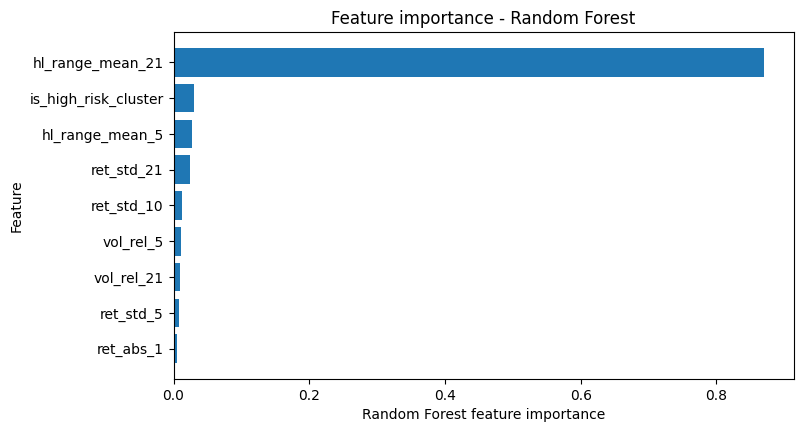

In [15]:

plt.figure(figsize=(8, 4.5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Feature importance - Random Forest")
plt.show()


In [16]:

# =========================
# Unseen / holdout evaluation
# =========================

unseen_df = pd.read_csv("data/unseen_holdout_raw.csv")
unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# Add trailing dev context before engineering features, same idea as current notebook
# We include enough raw history so rolling features at the start of unseen are valid.
dev_context_raw = (
    df_dev_raw
    .sort_values(["Symbol", "Date"])
    .groupby("Symbol", group_keys=False)
    .tail(21)
    .copy()
)

unseen_raw_with_context = (
    pd.concat([dev_context_raw, unseen_df], axis=0)
    .sort_values(["Symbol", "Date"])
    .drop_duplicates(subset=["Symbol", "Date"], keep="last")
    .reset_index(drop=True)
)

unseen_feat_all = engineer_features(unseen_raw_with_context)
unseen_feat = build_tabular_rows(
    unseen_feat_all,
    feature_cols,
    target_col,
    UNSEEN_START,
    UNSEEN_END,
    HORIZON,
)

print("unseen_feat:", unseen_feat.shape)


unseen_feat: (104290, 26)


In [17]:

X_unseen = unseen_feat[feature_cols].copy()
y_unseen = unseen_feat[target_col].copy()

unseen_results = unseen_feat[["Symbol", "Date", "Sector", "cluster", "Cluster_name", "ret_std_21"]].copy()
unseen_results["y_true"] = y_unseen.values
unseen_results["y_pred"] = rf.predict(X_unseen)
unseen_results["baseline_pred"] = unseen_results["ret_std_21"]

unseen_results.head()


,Symbol,Date,Sector,cluster,Cluster_name,ret_std_21,y_true,y_pred,baseline_pred
21,A,2025-03-21,Health Care,0.0,Lower-vol / steadier,0.019650,0.033387,0.018525,0.019650
22,A,2025-03-24,Health Care,0.0,Lower-vol / steadier,0.019915,0.033762,0.018915,0.019915
23,A,2025-03-25,Health Care,0.0,Lower-vol / steadier,0.019951,0.034191,0.019397,0.019951
24,A,2025-03-26,Health Care,0.0,Lower-vol / steadier,0.019941,0.034194,0.019484,0.019941
25,A,2025-03-27,Health Care,0.0,Lower-vol / steadier,0.019876,0.034265,0.019158,0.019876


In [18]:

rf_unseen_metrics = summarize_metrics(unseen_results, "y_pred")
base_unseen_metrics = summarize_metrics(unseen_results, "baseline_pred")

print("Unseen Random Forest:", rf_unseen_metrics)
print("Unseen Baseline:", base_unseen_metrics)


Unseen Random Forest: {'rmse': 0.008307347678226249, 'mae': 0.005520991502053865, 'r2': 0.3160789519459105, 'corr': 0.5644949547014352}
Unseen Baseline: {'rmse': 0.011170382384429451, 'mae': 0.0074822928200057965, 'r2': -0.23656592852724545, 'corr': 0.4201924028204771}


In [19]:

# Unseen by stock

rows = []
for symbol, g in unseen_results.groupby("Symbol"):
    if len(g) < 5:
        continue
    rows.append({
        "Symbol": symbol,
        "rmse_rf": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_rf": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_rf": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g),
    })

by_stock_unseen = pd.DataFrame(rows)
by_stock_unseen["rmse_win"] = by_stock_unseen["rmse_rf"] < by_stock_unseen["rmse_baseline"]
by_stock_unseen["mae_win"] = by_stock_unseen["mae_rf"] < by_stock_unseen["mae_baseline"]
by_stock_unseen["corr_win"] = by_stock_unseen["corr_rf"] > by_stock_unseen["corr_baseline"]

print("Pct stocks where RF wins on RMSE:", by_stock_unseen["rmse_win"].mean())
print("Pct stocks where RF wins on MAE:", by_stock_unseen["mae_win"].mean())
print("Pct stocks where RF wins on Corr:", by_stock_unseen["corr_win"].mean())

by_stock_unseen.head()


Pct stocks where RF wins on RMSE: 0.9218436873747495
Pct stocks where RF wins on MAE: 0.9018036072144289
Pct stocks where RF wins on Corr: 0.8276553106212425


,Symbol,rmse_rf,rmse_baseline,mae_rf,mae_baseline,corr_rf,corr_baseline,n_obs,rmse_win,mae_win,corr_win
0,A,0.005166,0.007216,0.004054,0.006117,0.313758,0.132117,209,True,True,True
1,AAPL,0.008336,0.012119,0.005464,0.008184,0.440913,0.326988,209,True,True,True
2,ABBV,0.005662,0.006712,0.004741,0.005398,0.233679,0.051970,209,True,True,True
3,ABNB,0.008587,0.010207,0.007517,0.007800,0.317621,0.287510,209,True,True,True
4,ABT,0.006240,0.007251,0.005381,0.005410,-0.301946,-0.272806,209,True,True,False


In [20]:

# Unseen by sector

rows = []
for sector, g in unseen_results.groupby("Sector"):
    if len(g) < 20:
        continue
    rows.append({
        "Sector": sector,
        "rmse_rf": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_rf": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "corr_rf": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g),
    })

by_sector_unseen = pd.DataFrame(rows)
by_sector_unseen["rmse_win"] = by_sector_unseen["rmse_rf"] < by_sector_unseen["rmse_baseline"]
by_sector_unseen["mae_win"] = by_sector_unseen["mae_rf"] < by_sector_unseen["mae_baseline"]
by_sector_unseen["corr_win"] = by_sector_unseen["corr_rf"] > by_sector_unseen["corr_baseline"]

by_sector_unseen.sort_values("rmse_rf").head(20)


,Sector,rmse_rf,rmse_baseline,mae_rf,mae_baseline,corr_rf,corr_baseline,n_obs,rmse_win,mae_win,corr_win
10,Utilities,0.005442,0.006459,0.003998,0.003932,0.790677,0.713193,6479,True,False,True
9,Real Estate,0.005637,0.007135,0.004231,0.005237,0.413078,0.301513,6479,True,True,True
2,Consumer Staples,0.006186,0.008406,0.004205,0.005619,0.433313,0.274203,7524,True,True,True
6,Industrials,0.007129,0.010020,0.005068,0.007144,0.529006,0.339686,16302,True,True,True
4,Financials,0.007649,0.010388,0.005074,0.006715,0.552444,0.422881,15883,True,True,True
3,Energy,0.007734,0.011119,0.005096,0.007241,0.425492,0.287960,4598,True,True,True
8,Materials,0.007880,0.010502,0.005582,0.007567,0.533292,0.391324,5434,True,True,True
1,Consumer Discretionary,0.008042,0.011349,0.005572,0.008008,0.569885,0.396242,10032,True,True,True
5,Health Care,0.009726,0.013088,0.006331,0.008822,0.416358,0.221267,12331,True,True,True
0,Communication Services,0.010381,0.013800,0.006554,0.008842,0.478245,0.339566,4807,True,True,True


In [21]:

# Unseen by cluster

rows = []
for (cluster, name), g in unseen_results.groupby(["cluster", "Cluster_name"]):
    rows.append({
        "cluster": cluster,
        "Cluster_name": name,
        "rmse_rf": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "rmse_baseline": np.sqrt(mean_squared_error(g["y_true"], g["baseline_pred"])),
        "mae_rf": mean_absolute_error(g["y_true"], g["y_pred"]),
        "mae_baseline": mean_absolute_error(g["y_true"], g["baseline_pred"]),
        "r2_rf": r2_score(g["y_true"], g["y_pred"]),
        "r2_baseline": r2_score(g["y_true"], g["baseline_pred"]),
        "corr_rf": g["y_true"].corr(g["y_pred"]),
        "corr_baseline": g["y_true"].corr(g["baseline_pred"]),
        "n_obs": len(g),
    })

by_cluster_perf = pd.DataFrame(rows)
by_cluster_perf


,cluster,Cluster_name,rmse_rf,rmse_baseline,mae_rf,mae_baseline,r2_rf,r2_baseline,corr_rf,corr_baseline,n_obs
0,0.0,Lower-vol / steadier,0.007839,0.010493,0.005201,0.007041,0.241813,-0.358491,0.494687,0.360001,93631
1,1.0,Higher-vol / riskier,0.011640,0.015930,0.008330,0.011356,0.249226,-0.406165,0.505106,0.352591,10659


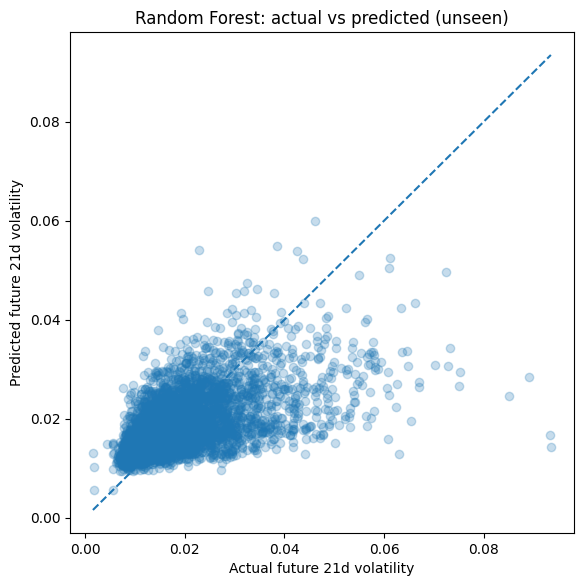

In [22]:

# Simple calibration plot on unseen

sample_plot = unseen_results.dropna(subset=["y_true", "y_pred"]).sample(
    n=min(5000, len(unseen_results)),
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(sample_plot["y_true"], sample_plot["y_pred"], alpha=0.25)
line_min = min(sample_plot["y_true"].min(), sample_plot["y_pred"].min())
line_max = max(sample_plot["y_true"].max(), sample_plot["y_pred"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("Actual future 21d volatility")
plt.ylabel("Predicted future 21d volatility")
plt.title("Random Forest: actual vs predicted (unseen)")
plt.show()



## Notes

If you want to tune the model next, the most useful parameters to try are:
- `n_estimators`
- `max_depth`
- `min_samples_leaf`
- `max_features`

A good next extension would be to compare:
1. baseline (`ret_std_21`)
2. linear / ridge regression
3. random forest
4. XGBoost / LightGBM
